## **Tutorial**

---

### **Advection–Diffusion Equation Unidimensional**

* **Domain:**
  $\Omega = [0,1]$

* **Governing equation:**
  $
  \mathrm{Pe} \,\phi_x - \phi_{xx} = 0, \quad x \in \Omega
  $

* **Boundary conditions:**
  $
  \phi(0) = 1 \quad \text{and} \quad \phi(1) = 0
  $


### **1. Packages**
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from typing import List, Mapping

from bernet.core import standard as std
from bernet.core import sampler as sp

from bernet.utils.processing import Losses

### **2. Hyperparameters**
---

In [2]:
#-- Model
neurons = [2, 5, 5, 1]
activation = torch.nn.Tanh()

#-- Loss
scale = 10.0

#-- Sampler
interior_h = 0.01
boundary_h = 0.01

#-- Optimizer
learning_rate = 1e-3
weight_decay = 1e-6

#-- Trainer
num_epochs = 300
verbose = True
filename = "advection-diffusion.log"

### **3. Implementation**
---

**Analytical Solution**

- Function definition

In [3]:
def analytical_solution(x: np.ndarray, peclet: float, tol: float = 1e-6) -> np.ndarray:
    return ( 1 - np.exp( (peclet + tol) * (x - 1) ) ) / ( 1 - np.exp(-(peclet + tol)) )

- Ploting solution

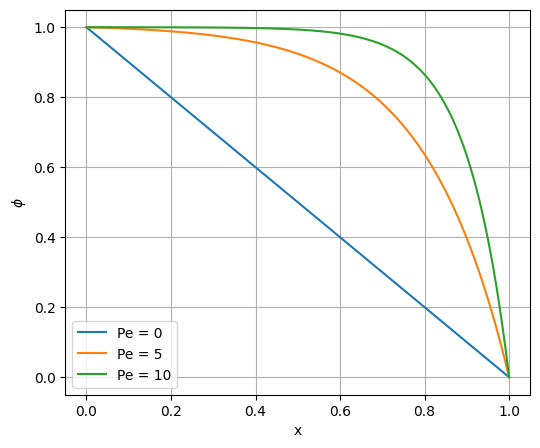

In [4]:
#-- Define the spatial domain
x = np.linspace(0, 1, 100)

#-- Compute the analytical solution
phi_Pe00 = analytical_solution(x=x, peclet=0)
phi_Pe05 = analytical_solution(x=x, peclet=5)
phi_Pe10 = analytical_solution(x=x, peclet=10)

#-- Plot the solution
plt.figure(figsize=(6, 5))
plt.plot(x, phi_Pe00, label="Pe = 0")
plt.plot(x, phi_Pe05, label="Pe = 5")
plt.plot(x, phi_Pe10, label="Pe = 10")
plt.xlabel("x")
plt.ylabel(r"$\phi$")
plt.legend()
plt.grid()
plt.show()

**Model**

In [5]:
class Model(torch.nn.Module):

    def __init__(
            self,
            neurons: List[int],
            activation: torch.nn.Module,
        ) -> None:
        super(Model, self).__init__()

        #-- Define a sequential model
        self.net = torch.nn.Sequential()

        #-- Add layers
        for i in range(len(neurons) - 1):
            self.net.append(torch.nn.Linear(neurons[i], neurons[i + 1]))
            if i < len(neurons) - 2:
                self.net.append(activation)
        
        return

    def forward(
            self,
            x: torch.Tensor,
        ) -> torch.Tensor:

        #-- Forward pass
        phi = self.net(x)

        return phi

**Loss**

In [ ]:
class Loss(std.LossBASE):

    def __init__(
            self,
            scale: float,
            func_bc = Losses.mse,
            func_in = Losses.mse,
            func_ob = Losses.mse,
        ):
        super().__init__(func_bc, func_in, func_ob)
        self._scale = scale
        return
    
    def residual(self, model: torch.nn.Module, batch: Mapping[str, torch.Tensor]) -> torch.Tensor:
        super().residual(model, batch)

        #-- Create model input with spatial derivatives allowed
        x_spatial = batch["x"][:, 0:1].detach().requires_grad_(True)
        x_peclet = batch["x"][:, 1:2].detach()

        x = torch.cat([x_spatial, x_peclet], dim=1)

        #-- Compute phi
        phi = model(x)

        #-- Derivatives
        phi_i = torch.autograd.grad(phi, x_spatial, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
        phi_ii = torch.autograd.grad(phi_i, x_spatial, grad_outputs=torch.ones_like(phi_i), create_graph=True)[0]
        
        #-- Residuals
        peclet = self._scale * x_peclet

        residual = (peclet * phi_i - phi_ii) / (peclet + 1)

        #-- Loss
        loss = torch.mean(residual * residual)

        return loss

### **4. Training**
---

Parameters

In [7]:
#-- Initialize parameters
model = Model(neurons, activation)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
loss = Loss(scale)

sampler = sp.Square(
    interior_h, boundary_h,
    keep_ratio=False,
    func=lambda x: analytical_solution(x[:, 0], scale * x[:, 1]).reshape(-1, 1),
    ratio_ob=0.1,
    remove=["bottom", "top"],
)

trainer = std.Trainer(
    model, sampler, loss, optimizer,
    metrics=["mse", "mae"],
    logger=std.Logger(),
    initialization="xavier_uniform",
)

Fit

In [8]:
#-- Realiza o treinamento
data = trainer.fit(num_epochs, verbose=verbose)

#-- Save training data
trainer.save(filename)

Epoch 1/300; | ILoss: 1.456e+00 (1.353e-01; 6.834e-01, 0.000e+00, 6.368e-01) | [mse: 1.590e-01, mae: 3.513e-01]
Epoch 2/300; | ILoss: 3.422e-01 (4.369e-02; 1.920e-01, 0.000e+00, 1.065e-01) | [mse: 7.442e-02, mae: 2.438e-01]
Epoch 3/300; | ILoss: 2.757e-01 (6.117e-02; 1.514e-01, 0.000e+00, 6.312e-02) | [mse: 5.760e-02, mae: 2.172e-01]
Epoch 4/300; | ILoss: 2.551e-01 (6.233e-02; 1.393e-01, 0.000e+00, 5.341e-02) | [mse: 5.144e-02, mae: 2.058e-01]
Epoch 5/300; | ILoss: 2.435e-01 (6.226e-02; 1.318e-01, 0.000e+00, 4.948e-02) | [mse: 4.564e-02, mae: 1.955e-01]
Epoch 6/300; | ILoss: 2.334e-01 (6.012e-02; 1.315e-01, 0.000e+00, 4.178e-02) | [mse: 4.245e-02, mae: 1.890e-01]
Epoch 7/300; | ILoss: 2.303e-01 (6.153e-02; 1.273e-01, 0.000e+00, 4.145e-02) | [mse: 3.902e-02, mae: 1.814e-01]
Epoch 8/300; | ILoss: 2.238e-01 (6.158e-02; 1.222e-01, 0.000e+00, 4.006e-02) | [mse: 4.167e-02, mae: 1.897e-01]
Epoch 9/300; | ILoss: 2.200e-01 (6.180e-02; 1.186e-01, 0.000e+00, 3.966e-02) | [mse: 3.771e-02, mae: 1.7

### **5. Results**
---

Training data

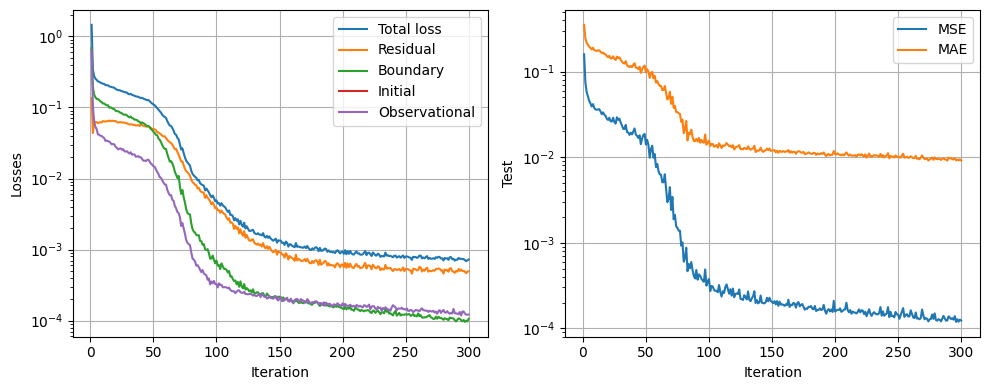

In [9]:
#-- Figures
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#-  Left plot: Losses
axes[0].plot(data["iteration"], data["loss"], label="Total loss")
axes[0].plot(data["iteration"], data["residual"], label="Residual")
axes[0].plot(data["iteration"], data["boundary"], label="Boundary")
axes[0].plot(data["iteration"], data["initial"], label="Initial")
axes[0].plot(data["iteration"], data["observational"], label="Observational")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Losses")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid()

#-  Right plot: Metrics
axes[1].plot(data["iteration"], data["mse [test]"], label="MSE")
axes[1].plot(data["iteration"], data["mae [test]"], label="MAE")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Test")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

Field prediction

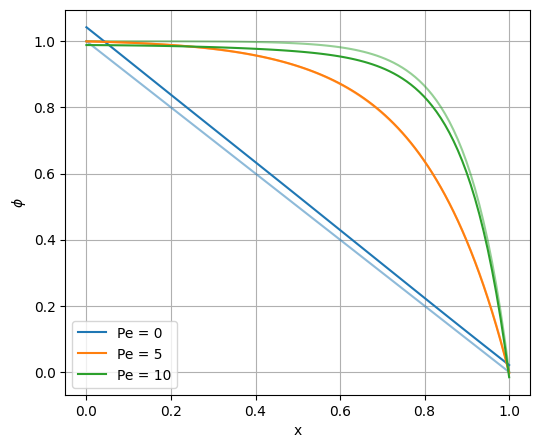

In [10]:
#-- Define the spatial domain
n = 100
x = np.linspace(0, 1, n)

#-- Compute the analytical solution
phi_Pe00 = analytical_solution(x=x, peclet=0)
phi_Pe05 = analytical_solution(x=x, peclet=5)
phi_Pe10 = analytical_solution(x=x, peclet=10)

#-- Predicted solution
model.eval()

x_Pe00 = torch.cat([torch.from_numpy(x).view(-1, 1), torch.zeros(n, 1)], dim=1).to(dtype=torch.float32)
phi_hat_Pe00 = model(x_Pe00).detach().numpy()

x_Pe05 = torch.cat([torch.from_numpy(x).view(-1, 1), 0.5 * torch.ones(n, 1)], dim=1).to(dtype=torch.float32)
phi_hat_Pe05= model(x_Pe05).detach().numpy()

x_Pe10 = torch.cat([torch.from_numpy(x).view(-1, 1), 1.0 * torch.ones(n, 1)], dim=1).to(dtype=torch.float32)
phi_hat_Pe10= model(x_Pe10).detach().numpy()

#-- Plot the solution
plt.figure(figsize=(6, 5))

plt.plot(x, phi_Pe00, color="#1f77b4", alpha=0.5)
plt.plot(x, phi_Pe05, color="#ff7f0e", alpha=0.5)
plt.plot(x, phi_Pe10, color="#2ca02c", alpha=0.5)

plt.plot(x, phi_hat_Pe00, color="#1f77b4", label="Pe = 0")
plt.plot(x, phi_hat_Pe05, color="#ff7f0e", label="Pe = 5")
plt.plot(x, phi_hat_Pe10, color="#2ca02c", label="Pe = 10")

plt.xlabel("x")
plt.ylabel(r"$\phi$")
plt.legend()
plt.grid()
plt.show()